Canonical correlation analysis for 3 principals components

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from neurostatx.io.loader import DatasetLoader
from neurostatx.utils.preprocessing import merge_dataframes
from neurostatx.statistics.models import permutation_testing
from neurostatx. io.viz import generate_coef_plot

from scipy import stats
from scipy.stats import false_discovery_control
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.multitest import multipletests
from itertools import product

from sklearn.impute import KNNImputer  
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
ping_bundles_resid_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/PCA/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
ping_bundles_resid = pd.read_excel(f"{ping_bundles_resid_dir}/ping_bundles_residualized.xlsx")

Avec principal component 1 : Magnitude de la diffusion

In [6]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
bundles_cols = ping_bundles_resid.columns[15:]
pc1_cols = [col for col in bundles_cols if str(col).startswith("('PC1',")]
X1 = ping_bundles_resid.loc[:, pc1_cols]
X1.index = ping_bundles_resid.index

Y1 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y1.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X1_c, Y1_c = cca.fit_transform(X1, Y1)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X1_c[:, i], Y1_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

bundle_labels = [col.split(", ")[1].strip("')") for col in X1.columns]

cca.score(X1, Y1)  # R² global de la CCA


Dimension canonique 1 : r = 0.360
Dimension canonique 2 : r = 0.297
Dimension canonique 3 : r = 0.259


0.07581372102949253

In [53]:
# Performing permutation testing
mod1, score1, coef1, perm_score1, score_pval1, perm_coef1, coef_pval1 = permutation_testing(
    cca,
    X1,
    Y1,
    nb_permutations=10000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   19.8s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   33.0s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   45.1s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  1.9min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  2.5min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  3.2min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  4.1min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  5.0min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  5.9min
[Parallel(n_jobs=4)]: Done 6042 tasks      | elapsed:  7.1min
[Parallel(n_jobs=4)]: Done 7192 tasks      | elapsed:  8.3min
[Parallel(n_jobs=4)]: Done 8442 tasks      | elapsed: 10.5min
[Parallel(n_jobs=4)]: Done 9792 tasks      | elapsed: 12.3min
[Parallel(n_jobs=4)]: Done 10000 out of 10000 | elapsed: 12.7

In [55]:
# Exporter les coefficients et les p-values dans des fichiers Excel
vars = ["AF_L", "AF_R", "CC_Fr_1", "CC_Fr_2", "CC_Oc", "CC_Pa", "CC_Pr_Po", "CC_Te",
        "CG_L", "CG_R", "FAT_L", "FAT_R", "FPT_L", "FPT_R", "FX_L", "FX_R", "ICP_L", "ICP_R",
        "IFOF_L", "IFOF_R", "ILF_L", "ILF_R", "MCP", "MdLF_L", "MdLF_R", "OR_ML_L", "OR_ML_R",
        "POPT_L", "POPT_R", "PYT_L", "PYT_R", "SCP_L", "SCP_R", "SLF_L", "SLF_R", "UF_L", "UF_R"]

coef_df1 = pd.DataFrame(
    cca.coef_.T,
    columns=[f"coef{i+1}" for i in range(cca.coef_.T.shape[1])]
)
coef_df1["varname"] = vars
coef_df1.to_excel(f"{output_dir}/CCA1/cca1_coef.xlsx", index=False, header=True)

coef_pval_df1 = pd.DataFrame(coef_pval1, index=bundle_labels, columns=Y1.columns)
    
# Control for false discovery rate
coef_pval_corr1 = pd.DataFrame()
for col in coef_pval_df1.columns:
    coef_pval_corr1[f"{col}_fdr_corrected"] = false_discovery_control(coef_pval_df1[col], method="bh")
coef_pval_corr1.index = coef_pval_df1.index

coef_pval_df1.to_excel(f"{output_dir}/CCA1/cca1_coef_pval.xlsx", index=True, header=True)
coef_pval_corr1.to_excel(f"{output_dir}/CCA1/cca1_coef_pval_fdr_corrected.xlsx", index=True, header=True)


In [56]:
# Générer les plots pour chaque variable cognitive
for i in range(0, Y1.shape[1]):
    generate_coef_plot(
        coef_df1,
        coef_pval_corr1.values[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/CCA1/cca1_coef_{i+1}.png"
    )

In [ ]:
# Calculer les loadings des faisceaux pour la première dimension canonique 
bundles_scores_1 = X1_c[:, 0]

bundles_loadings_1 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in X1.columns],
    "loading_CCA1": [np.corrcoef(X1.iloc[:, j], bundles_scores_1)[0, 1] for j in range(X1.shape[1])]
})
bundles_loadings_1["varname"] = vars

# Plot the loadings of X1
color = sns.color_palette("Set3")[7]

plotting_parameters = {
    "data" : bundles_loadings_1,
    "x" : "varname",
    "y" : "loading_CCA1",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(12, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-0.6, 0.6)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA1/cca1_bundles_loadings.png", dpi=900)
    plt.show


In [123]:
#  Calculer les loadings des variables cognitives pour la 2e dimension canonique
cog_scores_1 = Y1_c[:, 0]

cog_loadings_1 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in Y1.columns],
    "loading_CCA1": [np.corrcoef(Y1.iloc[:, j], cog_scores_1)[0, 1] for j in range(Y1.shape[1])]
})

# Plot the loadings of Y1
color = sns.color_palette("Set3")[4]

plotting_parameters = {
    "data" : cog_loadings_1,
    "x" : "varname",
    "y" : "loading_CCA1",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(4, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-1.1, 0.2)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA1/cca1_cog_loadings.png", dpi=900)
    plt.show


In [118]:
# Plot a scatter plot for the first canonical dimension of CCA1
x1_data, y1_data = mod1.transform(X1, Y1)

color = sns.color_palette("Set2")[3]

plotting_parameters = {
    "x" : x1_data[:, 0],
    "y" : y1_data[:, 0],
    "scatter_kws" : {"edgecolor" : "k", "alpha" : 0.7,
                     "s" : 120,
                     "color" : color},
    "line_kws" : {"linewidth" : 1, "color" : "r"},
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = sns.regplot(ax=ax, **plotting_parameters)

    ax.spines[["left", "bottom"]].set(linewidth=2)
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_ylabel("1$^{ère}$ dimension cognitive", fontdict={"fontweight": "bold"})
    ax.set_xlabel("1$^{ère}$ dimension des faisceaux", fontdict={"fontweight" : "bold"})

    ax.set_xlim(-0.75, 0.75)
    ax.set_ylim(-3, 4)

    ax.figure.autofmt_xdate(rotation=60, ha="right")
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA1/cca1_scatter.png", dpi=900)
    plt.show

In [69]:
coef_df1.set_index("varname", inplace=True)
coef_df1.columns = ["VA", "EFPS", "MEM"]

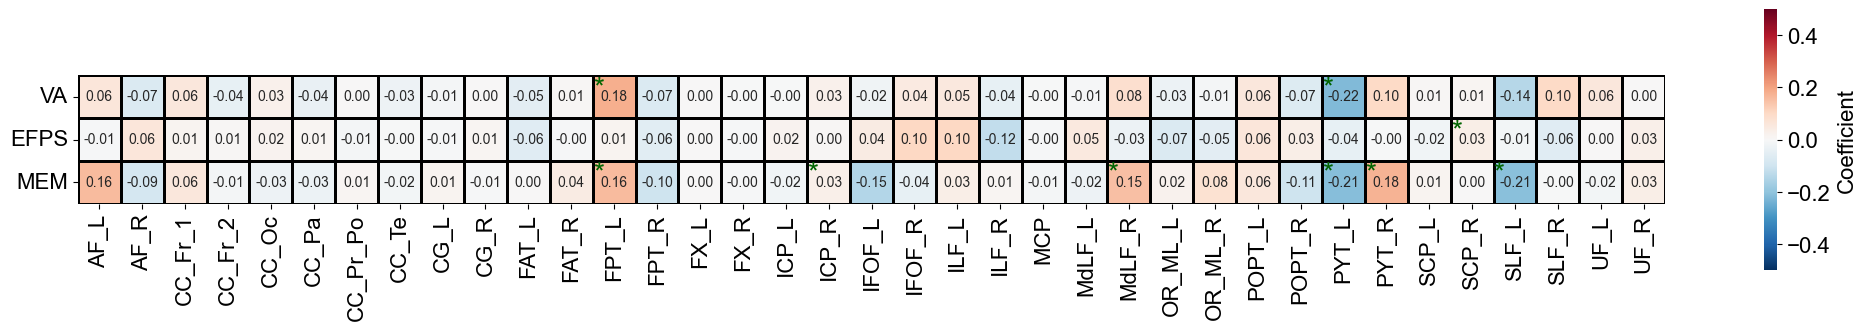

In [131]:
# Heatmap des coefficients de la CCA1

plotting_parameters1 = {
    "data" : coef_df1.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters1)

        ax.set_xlabel("")
        ax.set_title("")

        for i, j in product(range(coef_pval_df1.T.shape[0]), range(coef_pval_df1.T.shape[1])):
            if coef_pval_df1.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/CCA1/cca1_coef_heatmap.png", dpi=900)
        plt.show()

Avec principal component 2 : Complexité

In [7]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
pc2_cols = [col for col in bundles_cols if str(col).startswith("('PC2',")]
X2 = ping_bundles_resid.loc[:, pc2_cols]
X2.index = ping_bundles_resid.index

Y2 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y2.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X2_c, Y2_c = cca.fit_transform(X2, Y2)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X2_c[:, i], Y2_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

cca.score(X2, Y2)  # R² global de la CCA


Dimension canonique 1 : r = 0.376
Dimension canonique 2 : r = 0.337
Dimension canonique 3 : r = 0.293


0.10238301054044337

In [74]:
# Performing permutation testing
mod2, score2, coef2, perm_score2, score_pval2, perm_coef2, coef_pval2 = permutation_testing(
    cca,
    X2,
    Y2,
    nb_permutations=10000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   11.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   20.5s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   35.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:   51.4s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  1.9min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  4.2min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  5.5min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  7.0min
[Parallel(n_jobs=4)]: Done 6042 tasks      | elapsed:  8.5min
[Parallel(n_jobs=4)]: Done 7192 tasks      | elapsed: 10.1min
[Parallel(n_jobs=4)]: Done 8442 tasks      | elapsed: 11.7min
[Parallel(n_jobs=4)]: Done 9792 tasks      | elapsed: 13.4min
[Parallel(n_jobs=4)]: Done 10000 out of 10000 | elapsed: 13.6

In [75]:
coef_df2 = pd.DataFrame(
    cca.coef_.T,
    columns=[f"coef{i+1}" for i in range(cca.coef_.T.shape[1])]
)
coef_df2["varname"] = vars
coef_df2.to_excel(f"{output_dir}/CCA2/cca2_coef.xlsx", index=False, header=True)

coef_pval_df2 = pd.DataFrame(coef_pval2, index=bundle_labels, columns=Y2.columns)

# Control for false discovery rate
coef_pval_corr2 = pd.DataFrame()
for col in coef_pval_df2.columns:
    coef_pval_corr2[f"{col}_fdr_corrected"] = false_discovery_control(coef_pval_df2[col], method="bh")
coef_pval_corr2.index = coef_pval_df2.index

coef_pval_df2.to_excel(f"{output_dir}/CCA2/cca2_coef_pval.xlsx", index=True, header=True)
coef_pval_corr2.to_excel(f"{output_dir}/CCA2/cca2_coef_pval_fdr_corrected.xlsx", index=True, header=True)

In [76]:
# Générer les plots pour chaque variable cognitive
for i in range(0, Y2.shape[1]):
    generate_coef_plot(
        coef_df2,
        coef_pval_corr2.values[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/CCA2/cca2_coef_{i+1}.png"
    )

In [84]:
# Calculer les loadings des faisceaux pour la 2e dimension canonique 
bundles_scores_2 = X2_c[:, 0]

bundles_loadings_2 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in X2.columns],
    "loading_CCA2": [np.corrcoef(X2.iloc[:, j], bundles_scores_2)[0, 1] for j in range(X2.shape[1])]
})
bundles_loadings_2["varname"] = vars

# Plot the loadings of X2
color = sns.color_palette("Set3")[7]

plotting_parameters = {
    "data" : bundles_loadings_2,
    "x" : "varname",
    "y" : "loading_CCA2",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(12, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-0.5, 0.5)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA2/cca2_bundles_loadings.png", dpi=900)
    plt.show


In [124]:
#  Calculer les loadings des variables cognitives pour la 2e dimension canonique
cog_scores_2 = Y2_c[:, 0]

cog_loadings_2 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in Y2.columns],
    "loading_CCA2": [np.corrcoef(Y2.iloc[:, j], cog_scores_2)[0, 1] for j in range(Y2.shape[1])]
})

# Plot the loadings of Y2
color = sns.color_palette("Set3")[4]

plotting_parameters = {
    "data" : cog_loadings_2,
    "x" : "varname",
    "y" : "loading_CCA2",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(4, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-0.2, 1.1)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA2/cca2_cog_loadings.png", dpi=900)
    plt.show


In [125]:
# Plot a scatter plot for the first canonical dimension of CCA2
x2_data, y2_data = mod2.transform(X2, Y2)

color = sns.color_palette("Set2")[3]

plotting_parameters = {
    "x" : x2_data[:, 0],
    "y" : y2_data[:, 0],
    "scatter_kws" : {"edgecolor" : "k", "alpha" : 0.7,
                     "s" : 120,
                     "color" : color},
    "line_kws" : {"linewidth" : 1, "color" : "r"},
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = sns.regplot(ax=ax, **plotting_parameters)

    ax.spines[["left", "bottom"]].set(linewidth=2)
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_ylabel("1$^{ère}$ dimension cognitive", fontdict={"fontweight": "bold"})
    ax.set_xlabel("1$^{ère}$ dimension des faisceaux", fontdict={"fontweight" : "bold"})

    ax.set_xlim(-1.2, 0.80)
    ax.set_ylim(-4, 5)

    ax.figure.autofmt_xdate(rotation=60, ha="right")
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA2/cca2_scatter.png", dpi=900)
    plt.show

In [85]:
coef_df2.set_index("varname", inplace=True)
coef_df2.columns = ["VA", "EFPS", "MEM"]

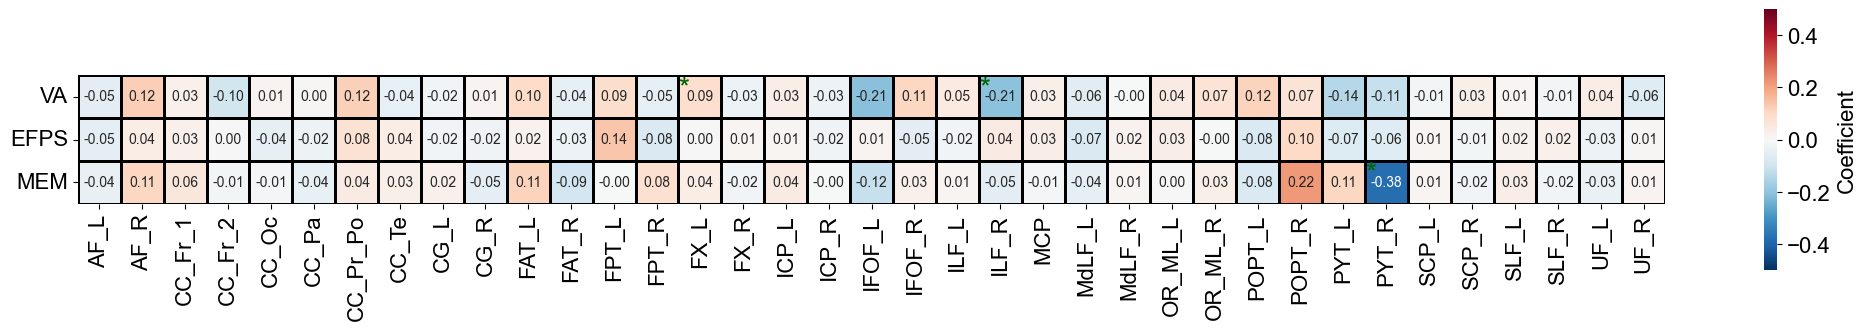

In [130]:
# Heatmap des coefficients de la CCA (PC2)

plotting_parameters2 = {
    "data" : coef_df2.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters2)

        ax.set_xlabel("")
        ax.set_title("")

        for i, j in product(range(coef_pval_df2.T.shape[0]), range(coef_pval_df2.T.shape[1])):
            if coef_pval_df2.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/CCA2/cca2_coef_heatmap.png", dpi=900)
        plt.show()

Avec principal component 3 : Densité axonal

In [8]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
pc3_cols = [col for col in bundles_cols if str(col).startswith("('PC3',")]
X3 = ping_bundles_resid.loc[:, pc3_cols]
X3.index = ping_bundles_resid.index

Y3 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y3.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X3_c, Y3_c = cca.fit_transform(X3, Y3)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X3_c[:, i], Y3_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

cca.score(X3, Y3)  # R² global de la CCA


Dimension canonique 1 : r = 0.363
Dimension canonique 2 : r = 0.341
Dimension canonique 3 : r = 0.271


0.05948166762982062

In [89]:
# Performing permutation testing
mod3, score3, coef3, perm_score3, score_pval3, perm_coef3, coef_pval3 = permutation_testing(
    cca,
    X3,
    Y3,
    nb_permutations=10000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   13.8s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   30.6s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   53.0s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  1.9min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  2.5min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  3.3min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  4.3min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  5.3min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  6.5min
[Parallel(n_jobs=4)]: Done 6042 tasks      | elapsed:  7.8min
[Parallel(n_jobs=4)]: Done 7192 tasks      | elapsed:  9.8min
[Parallel(n_jobs=4)]: Done 8442 tasks      | elapsed: 11.4min
[Parallel(n_jobs=4)]: Done 9792 tasks      | elapsed: 13.0min
[Parallel(n_jobs=4)]: Done 10000 out of 10000 | elapsed: 13.3

In [90]:
coef_df3 = pd.DataFrame(
    cca.coef_.T,
    columns=[f"coef{i+1}" for i in range(cca.coef_.T.shape[1])]
)
coef_df3["varname"] = vars
coef_df3.to_excel(f"{output_dir}/CCA3/cca3_coef.xlsx", index=False, header=True)

coef_pval_df3 = pd.DataFrame(coef_pval3, index=bundle_labels, columns=Y3.columns)
    
# Control for false discovery rate
coef_pval_corr3 = pd.DataFrame()
for col in coef_pval_df2.columns:
   coef_pval_corr3[f"{col}_fdr_corrected"] = false_discovery_control(coef_pval_df3[col], method="bh")
coef_pval_corr3.index = coef_pval_df3.index

coef_pval_df3.to_excel(f"{output_dir}/CCA3/cca3_coef_pval.xlsx", index=True, header=True)
coef_pval_corr3.to_excel(f"{output_dir}/CCA3/cca3_coef_pval_fdr_corrected.xlsx", index=True, header=True)

In [92]:
# Générer les plots pour chaque variable cognitive
for i in range(0, Y3.shape[1]):
    generate_coef_plot(
        coef_df3,
        coef_pval_corr3.values[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/CCA3/cca3_coef_{i+1}.png"
    )

In [94]:
# Calculer les loadings des faisceaux pour la 3e dimension canonique 
bundles_scores_3 = X3_c[:, 0]

bundles_loadings_3 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in X3.columns],
    "loading_CCA3": [np.corrcoef(X3.iloc[:, j], bundles_scores_3)[0, 1] for j in range(X3.shape[1])]
})
bundles_loadings_3["varname"] = vars

# Plot the loadings of X3
color = sns.color_palette("Set3")[7]

plotting_parameters = {
    "data" : bundles_loadings_3,
    "x" : "varname",
    "y" : "loading_CCA3",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(12, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-0.5, 0.6)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA3/cca3_bundles_loadings.png", dpi=900)
    plt.show

In [126]:
#  Calculer les loadings des variables cognitives pour la 3e dimension canonique
cog_scores_3 = Y3_c[:, 0]

cog_loadings_3 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in Y1.columns],
    "loading_CCA3": [np.corrcoef(Y3.iloc[:, j], cog_scores_3)[0, 1] for j in range(Y3.shape[1])]
})

# Plot the loadings of Y3
color = sns.color_palette("Set3")[4]

plotting_parameters = {
    "data" : cog_loadings_3,
    "x" : "varname",
    "y" : "loading_CCA3",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(4, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-1.0, 0.6)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA3/cca3_cog_loadings.png", dpi=900)
    plt.show


In [127]:
# Plot a scatter plot for the first canonical dimension of CCA3
x3_data, y3_data = mod3.transform(X3, Y3)

color = sns.color_palette("Set2")[3]

plotting_parameters = {
    "x" : x3_data[:, 0],
    "y" : y3_data[:, 0],
    "scatter_kws" : {"edgecolor" : "k", "alpha" : 0.7,
                     "s" : 120,
                     "color" : color},
    "line_kws" : {"linewidth" : 1, "color" : "r"},
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = sns.regplot(ax=ax, **plotting_parameters)

    ax.spines[["left", "bottom"]].set(linewidth=2)
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_ylabel("1$^{ère}$ dimension cognitive", fontdict={"fontweight": "bold"})
    ax.set_xlabel("1$^{ère}$ dimension des faisceaux", fontdict={"fontweight" : "bold"})

    ax.set_xlim(-0.31, 0.31)
    ax.set_ylim(-2, 2.5)

    ax.figure.autofmt_xdate(rotation=60, ha="right")
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/CCA3/cca3_scatter.png", dpi=900)
    plt.show

In [97]:
coef_df3.set_index("varname", inplace=True)
coef_df3.columns = ["VA", "EFPS", "MEM"]

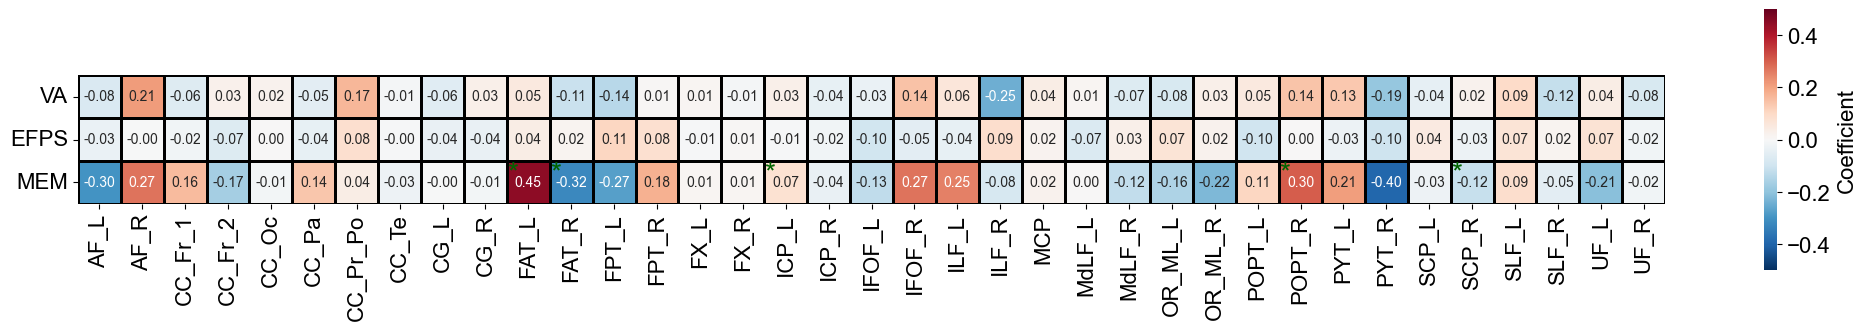

In [129]:
# Heatmap des coefficients de la CCA (PC3)

plotting_parameters3 = {
    "data" : coef_df3.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters3)

        ax.set_xlabel("")
        ax.set_title("")

        for i, j in product(range(coef_pval_df3.T.shape[0]), range(coef_pval_df3.T.shape[1])):
            if coef_pval_df3.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/CCA3/cca3_coef_heatmap.png", dpi=900)
        plt.show()